The CMAPSS dataset consists of 12 files: four training datasets, four test datasets, and four RUL label files.

First, the four training datasets are combined into a single dataset. From this dataset, the Remaining Useful Life (RUL) is calculated using the difference between the maximum cycle of each engine and the current cycle.

The model is then trained on this combined training dataset.

Next, the four test datasets are combined and preprocessed using the same steps applied to the training data, such as feature selection and normalization.

The trained model is then used to predict RUL for the test engines.

Finally, the predicted RUL values are compared with the actual RUL values provided in the RUL files to evaluate the model performance using metrics such as RMSE.

### Milestone 1: Data Ingestion & Initial Setup

In [1]:
# ==========================================================
# STEP 1 : IMPORT LIBRARIES
# ==========================================================

import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout

import matplotlib.pyplot as plt

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


### Loading CMAPSS Datasets

In [2]:
def load_cmapss(file_path, dataset_name):
    df = pd.read_csv(file_path, sep=r"\s+", header=None)
    columns = ['unit','cycle','op1','op2','op3'] + [f'sensor{i}' for i in range(1,22)]
    df.columns = columns
    df['dataset'] = dataset_name
    return df

In [3]:
# Load Training Data
df_train = pd.concat([
    load_cmapss("/content/drive/MyDrive/PrognosAI-Infy/Datasets/train_FD001.txt","FD001"),
    load_cmapss("/content/drive/MyDrive/PrognosAI-Infy/Datasets/train_FD002.txt","FD002"),
    load_cmapss("/content/drive/MyDrive/PrognosAI-Infy/Datasets/train_FD003.txt","FD003"),
    load_cmapss("/content/drive/MyDrive/PrognosAI-Infy/Datasets/train_FD004.txt","FD004")
], ignore_index=True)
df_train['unit_id'] = df_train['dataset'] + "_" + df_train['unit'].astype(str)

In [4]:
print("Total Engines:",df_train['unit_id'].nunique())

Total Engines: 709


In [5]:
# Calculate RUL for Training Data
max_cycle_train = df_train.groupby('unit_id')['cycle'].max().reset_index()
max_cycle_train.columns = ['unit_id','max_cycle']
df_train = df_train.merge(max_cycle_train, on='unit_id')
df_train['RUL'] = df_train['max_cycle'] - df_train['cycle']
df_train['RUL'] = df_train['RUL'].clip(upper=195) # Corrected Clip
df_train.drop(columns=['max_cycle'], inplace=True)

In [6]:
# Define feature columns (dropping non-informative sensors)
drop_cols = ['sensor1','sensor5','sensor6','sensor10','sensor16','sensor18','sensor19']
feature_cols = ['op1','op2','op3'] + [col for col in df_train.columns if 'sensor' in col and col not in drop_cols]

In [7]:
df_train.to_csv("CMAPSS_train.csv", index=False)
print("Dataset saved successfully")

Dataset saved successfully


In [8]:
# Load Test Data
df_test = pd.concat([
    load_cmapss("/content/drive/MyDrive/PrognosAI-Infy/Datasets/test_FD001.txt","FD001"),
    load_cmapss("/content/drive/MyDrive/PrognosAI-Infy/Datasets/test_FD002.txt","FD002"),
    load_cmapss("/content/drive/MyDrive/PrognosAI-Infy/Datasets/test_FD003.txt","FD003"),
    load_cmapss("/content/drive/MyDrive/PrognosAI-Infy/Datasets/test_FD004.txt","FD004")
], ignore_index=True)
df_test['unit_id'] = df_test['dataset'] + "_" + df_test['unit'].astype(str)

In [9]:
df_test.to_csv("CMAPSS_test.csv", index=False)
print("Dataset saved successfully")

Dataset saved successfully


### STEP 5: LOAD GROUND TRUTH (RUL)

In [10]:
def load_combined_rul(paths):
    rul_list = []
    # These match the order of your test file concatenations
    datasets = ["FD001", "FD002", "FD003", "FD004"]
    for path, ds in zip(paths, datasets):
        df = pd.read_csv(path, header=None, names=['RUL'])
        df['dataset'] = ds
        # Create unique IDs to match your df_test structure
        df['unit'] = df.index + 1
        df['unit_id'] = df['dataset'] + "_" + df['unit'].astype(str)
        rul_list.append(df)
    return pd.concat(rul_list, ignore_index=True)

In [11]:
# Update these paths to match your Google Drive location
rul_paths = [
    "/content/drive/MyDrive/PrognosAI-Infy/Datasets/RUL_FD001.txt",
    "/content/drive/MyDrive/PrognosAI-Infy/Datasets/RUL_FD002.txt",
    "/content/drive/MyDrive/PrognosAI-Infy/Datasets/RUL_FD003.txt",
    "/content/drive/MyDrive/PrognosAI-Infy/Datasets/RUL_FD004.txt"
]

df_rul_actual = load_combined_rul(rul_paths)
print(f"Loaded actual RUL for {len(df_rul_actual)} engines.")

Loaded actual RUL for 707 engines.


In [12]:
# Saving the combined Ground Truth RUL labels
df_rul_actual.to_csv("CMAPSS_test_rul.csv", index=False)
print("RUL Ground Truth labels saved successfully")

RUL Ground Truth labels saved successfully



### STEP 2: SCALING & SEQUENCE PREPARATION

In [13]:
# 1. Scale Features
scaler_features = StandardScaler()
df_train[feature_cols] = scaler_features.fit_transform(df_train[feature_cols])
df_test[feature_cols] = scaler_features.transform(df_test[feature_cols])

## Milestone 2: Sequence Engineering

In [14]:
# 2. Define the Sequence Creation Function
def create_sequences(dataframe, seq_length, feature_cols):
    X, y = [], []
    for unit in dataframe['unit_id'].unique():
        unit_df = dataframe[dataframe['unit_id'] == unit]
        data = unit_df[feature_cols].values
        rul = unit_df['RUL'].values
        for i in range(len(unit_df) - seq_length + 1):
            X.append(data[i:i + seq_length])
            y.append(rul[i + seq_length - 1])
    return np.array(X), np.array(y)

In [15]:
# 3. Generate Training Sequences
SEQ_LENGTH = 30
X_train, y_train_raw = create_sequences(df_train, SEQ_LENGTH, feature_cols)

In [16]:
# 4. Scale the Target RUL
# Standardizing the target helps neural networks converge faster
scaler_y = StandardScaler()
y_train = scaler_y.fit_transform(y_train_raw.reshape(-1, 1))

In [17]:
print("Feature and Target scaling complete.")
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")

Feature and Target scaling complete.
X_train shape: (139798, 30, 17), y_train shape: (139798, 1)


In [18]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import Huber
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import Huber
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

## Milestone 3: Deep Learning Model Development

### LSTM model architecture.

In [19]:
# Define Architecture
lstm_model = Sequential()

lstm_model.add(LSTM(64, return_sequences=True, input_shape=(SEQ_LENGTH, len(feature_cols))))
lstm_model.add(Dropout(0.2))

lstm_model.add(LSTM(32))
lstm_model.add(Dropout(0.2))

lstm_model.add(Dense(16, activation='relu'))
lstm_model.add(Dense(1))

lstm_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss=Huber(),
    metrics=['mae']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [20]:
# Set up Early Stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [21]:
# Train the Model
history_lstm = lstm_model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=128,
    validation_split=0.1,
    callbacks=[early_stop]
)

Epoch 1/50
983/983 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - loss: 0.1825 - mae: 0.4816 - val_loss: 0.1602 - val_mae: 0.4451
Epoch 2/50
983/983 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - loss: 0.1448 - mae: 0.4195 - val_loss: 0.1576 - val_mae: 0.4408
Epoch 3/50
983/983 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 0.1361 - mae: 0.4034 - val_loss: 0.1464 - val_mae: 0.4287
Epoch 4/50
983/983 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - loss: 0.1300 - mae: 0.3927 - val_loss: 0.1370 - val_mae: 0.4025
Epoch 5/50
983/983 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - loss: 0.1249 - mae: 0.3835 - val_loss: 0.1381 - val_mae: 0.3964
Epoch 6/50
983/983 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 0.1222 - mae: 0.3778 - val_loss: 0.1213 - val_mae: 0.3786
Epoch 7/50
983/983 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - loss: 0.1181 - mae: 0.3702 - val_loss: 0.1282 - val_mae: 0.3944
Epoch 8/50
983/983 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 0.1149 - mae: 0.3647 - val_loss: 0.1248 - val_mae: 0.3812
Epoch 9/50
983/983 ━━━━━━━━━━━━━━━━━━━━ 10

### Training vs validation loss for LSTM model.

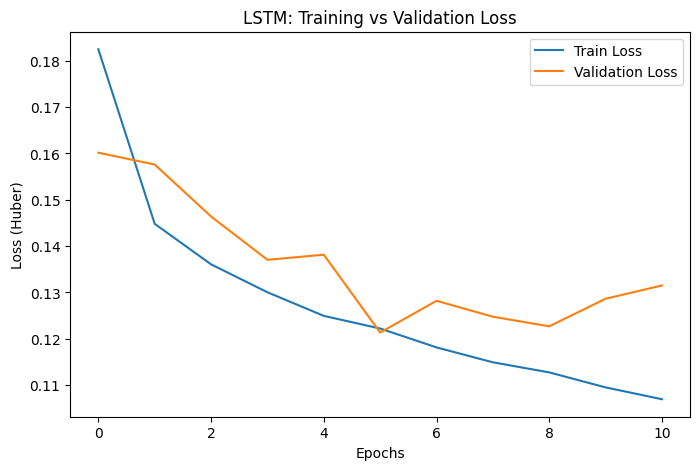

In [22]:
plt.figure(figsize=(8, 5))
plt.plot(history_lstm.history['loss'], label="Train Loss")
plt.plot(history_lstm.history['val_loss'], label="Validation Loss")
plt.title("LSTM: Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss (Huber)")
plt.legend()
plt.show()

### Build the GRU model for comparison.


### GRU model architecture.

In [23]:
from tensorflow.keras.layers import GRU

# Initialize GRU model
gru_model = Sequential()

# GRU layers are often faster and can be more robust to noise in CMAPSS
gru_model.add(GRU(64, return_sequences=True, input_shape=(SEQ_LENGTH, len(feature_cols))))
gru_model.add(Dropout(0.2))

gru_model.add(GRU(32))
gru_model.add(Dropout(0.2))

gru_model.add(Dense(16, activation='relu'))
gru_model.add(Dense(1))

gru_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss=Huber(),
    metrics=['mae']
)

In [24]:
# Train the GRU model
history_gru = gru_model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=128,
    validation_split=0.1,
    callbacks=[early_stop] # Reuse the same early_stop logic
)

Epoch 1/50
983/983 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - loss: 0.1897 - mae: 0.4919 - val_loss: 0.1629 - val_mae: 0.4502
Epoch 2/50
983/983 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - loss: 0.1454 - mae: 0.4212 - val_loss: 0.1567 - val_mae: 0.4524
Epoch 3/50
983/983 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - loss: 0.1350 - mae: 0.4019 - val_loss: 0.1497 - val_mae: 0.4553
Epoch 4/50
983/983 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 0.1302 - mae: 0.3933 - val_loss: 0.1392 - val_mae: 0.4093
Epoch 5/50
983/983 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - loss: 0.1255 - mae: 0.3850 - val_loss: 0.1332 - val_mae: 0.4127


### Training vs validation loss for GRU model.

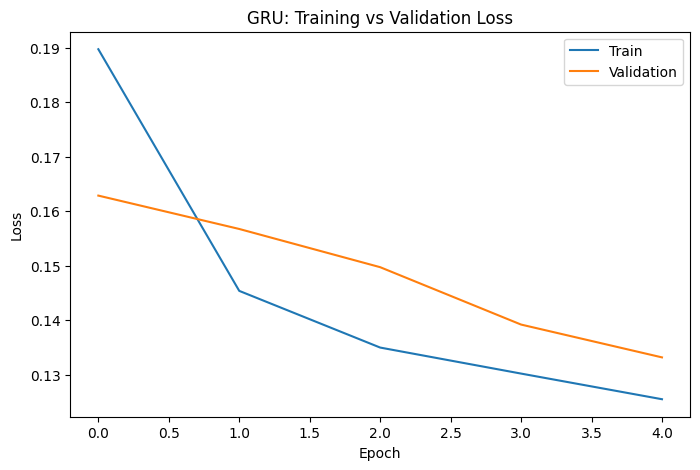

In [25]:
# Graph the GRU Loss
plt.figure(figsize=(8,5))
plt.plot(history_gru.history['loss'], label="Train")
plt.plot(history_gru.history['val_loss'], label="Validation")
plt.title("GRU: Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [31]:
# Define the 17 features your model was built for
sensor_cols = [
    'op1', 'op2', 'op3',
    'sensor2', 'sensor3', 'sensor4', 'sensor7', 'sensor8', 'sensor9',
    'sensor11', 'sensor12', 'sensor13', 'sensor14', 'sensor15',
    'sensor17', 'sensor20', 'sensor21'
]

print(f"Successfully defined {len(sensor_cols)} features.")

Successfully defined 17 features.


In [32]:
from sklearn.preprocessing import StandardScaler
import joblib

# --- FEATURE SCALER ---
feature_scaler = StandardScaler()

# Use 'df_train' (matching your column output)
X_train_scaled = feature_scaler.fit_transform(df_train[sensor_cols])

# Save immediately - this file will now be "Fitted"
joblib.dump(feature_scaler, 'feature_scaler.pkl')


# --- TARGET SCALER (RUL) ---
target_scaler = StandardScaler()
y_train_scaled = target_scaler.fit_transform(df_train[['RUL']])

# Save
joblib.dump(target_scaler, 'target_scaler.pkl')

print("Scalers fitted and saved successfully!")

Scalers fitted and saved successfully!


In [27]:

lstm_model.save('lstm_rul_model.keras')

gru_model.save('gru_rul_model.keras')

print("Models saved successfully in .keras format!")

Models saved successfully in .keras format!


## Evaluate model performance using RMSE.

In [33]:
import numpy as np

In [34]:
def prepare_test_data(test_df, seq_length, feature_cols):
    test_sequences = []
    for unit in test_df['unit_id'].unique():
        unit_data = test_df[test_df['unit_id'] == unit]
        data_values = unit_data[feature_cols].values

        # Take the last window of data for prediction
        if len(data_values) >= seq_length:
            last_window = data_values[-seq_length:]
        else:
            # Pad with zeros if engine has fewer than SEQ_LENGTH cycles
            padding = np.zeros((seq_length - len(data_values), len(feature_cols)))
            last_window = np.vstack((padding, data_values))

        test_sequences.append(last_window)
    return np.array(test_sequences)

In [35]:
# Ensure SEQ_LENGTH is 30 (same as training)
X_test = prepare_test_data(df_test, 30, feature_cols)
print(f"X_test prepared with shape: {X_test.shape}")

X_test prepared with shape: (707, 30, 17)


## Predict RUL using LSTM and GRU models.

In [36]:
# 1. Get Scaled Predictions
y_pred_lstm_scaled = lstm_model.predict(X_test)
y_pred_gru_scaled = gru_model.predict(X_test)

23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step


In [37]:
# 2. Inverse Transform to Cycles
y_pred_lstm = scaler_y.inverse_transform(y_pred_lstm_scaled).flatten()
y_pred_gru = scaler_y.inverse_transform(y_pred_gru_scaled).flatten()

In [38]:
# 3. Calculate Individual RMSE
y_actual = df_rul_actual['RUL'].values
rmse_lstm = np.sqrt(mean_squared_error(y_actual, y_pred_lstm))
rmse_gru = np.sqrt(mean_squared_error(y_actual, y_pred_gru))

### combining their outputs using ensemble averaging, corrected test labels using the CMAPSS RUL files, and implemented a threshold-based alert system to classify equipment health.

In [39]:
print(f"LSTM RMSE: {rmse_lstm:.2f}")
print(f"GRU RMSE: {rmse_gru:.2f}")

# 4. Weighted Ensemble (60% GRU / 40% LSTM)
y_pred_final = (0.6 * y_pred_gru) + (0.4 * y_pred_lstm)
rmse_ensemble = np.sqrt(mean_squared_error(y_actual, y_pred_final))

print(f"Final Weighted Ensemble RMSE: {rmse_ensemble:.2f}")

LSTM RMSE: 26.52
GRU RMSE: 32.62
Final Weighted Ensemble RMSE: 28.76


# Milestone 4 - Risk Thresholding & Alerts

In [41]:
# 1. Standardized Alert Logic
def get_maintenance_status(predicted_rul):
    if predicted_rul <= 25:
        return "RED: CRITICAL"
    elif predicted_rul <= 55:
        return "ORANGE: WARNING"
    else:
        return "GREEN: HEALTHY"


In [42]:
# 2. Create the Master Dataframe (Use final_results consistently)
final_results = pd.DataFrame({
    'Engine_ID': df_test['unit_id'].unique(),
    'Predicted_RUL': y_pred_final.round(1),
    'Actual_RUL': y_actual,
    'Status': [get_maintenance_status(x) for x in y_pred_final]
})

In [43]:
# 3. Calculate Error Column for Plotting
final_results['Error'] = final_results['Actual_RUL'] - final_results['Predicted_RUL']

#### Final results table

In [44]:
# View engines that need immediate attention
at_risk = final_results[final_results['Status'] != "GREEN: HEALTHY"]
print(f"Total Engines requiring attention: {len(at_risk)}")
at_risk.head(5)

Total Engines requiring attention: 221


,Engine_ID,Predicted_RUL,Actual_RUL,Status,Error
16,FD001_17,51.400002,50,ORANGE: WARNING,-1.400002
19,FD001_20,24.000000,16,RED: CRITICAL,-8.000000
23,FD001_24,22.000000,20,RED: CRITICAL,-2.000000
30,FD001_31,17.799999,8,RED: CRITICAL,-9.799999
33,FD001_34,14.600000,7,RED: CRITICAL,-7.600000


### Alert distribution

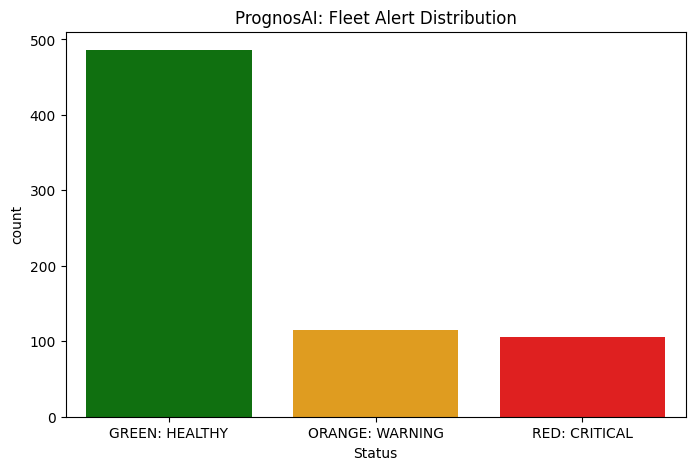

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
sns.countplot(
    data=final_results,
    x='Status',
    palette={'GREEN: HEALTHY': 'green', 'ORANGE: WARNING': 'orange', 'RED: CRITICAL': 'red'},
    order=['GREEN: HEALTHY', 'ORANGE: WARNING', 'RED: CRITICAL'],
    hue='Status',
    legend=False
)
plt.title("PrognosAI: Fleet Alert Distribution")
plt.show()

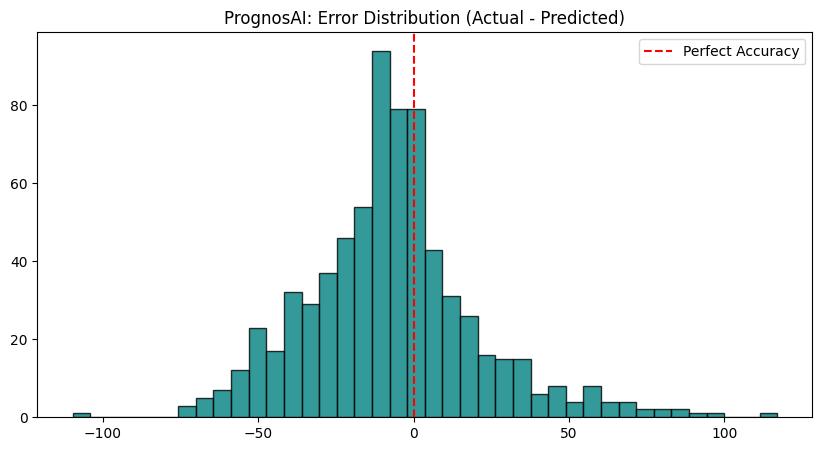

Mean Prediction Error: -7.01 cycles


In [46]:
plt.figure(figsize=(10, 5))
plt.hist(final_results['Error'], bins=40, color='teal', edgecolor='black', alpha=0.8)
plt.title("PrognosAI: Error Distribution (Actual - Predicted)")
plt.axvline(0, color='red', linestyle='--', label='Perfect Accuracy')
plt.legend()
plt.show()

print(f"Mean Prediction Error: {final_results['Error'].mean():.2f} cycles")

# Milestone 5 - Visualization & Output

#### Actual vs Predicted

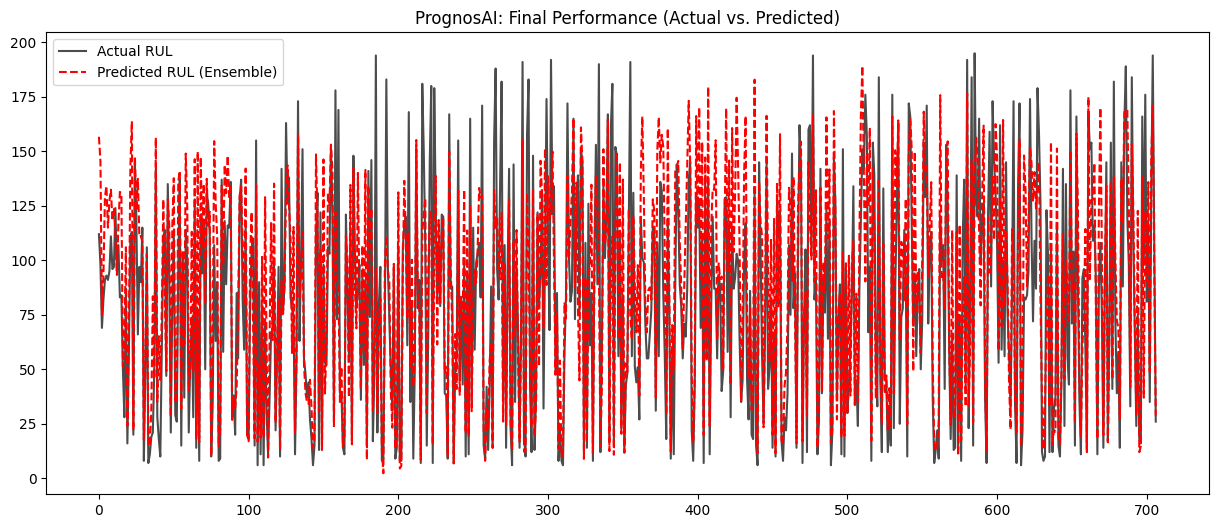

In [47]:
plt.figure(figsize=(15, 6))
plt.plot(final_results['Actual_RUL'], label="Actual RUL", color='black', alpha=0.7)
plt.plot(final_results['Predicted_RUL'], label="Predicted RUL (Ensemble)", color='red', linestyle='--')
plt.title("PrognosAI: Final Performance (Actual vs. Predicted)")
plt.legend()
plt.show()

In [48]:
final_results.to_csv('PrognosAI_Maintenance_Report.csv', index=False)
print("Project complete. Report saved as CSV.")

Project complete. Report saved as CSV.


Sensor Data:
1. Sequence Creation
2. LSTM + GRU Models
3. Ensemble Averaging
4. RUL Prediction (scaled → inverse scaled)
5. Threshold-based Alerts
6. Visualization & Output

**Built a predictive maintenance system to estimate Remaining Useful Life (RUL) using time-series sensor data.
LSTM and GRU models were trained to capture degradation patterns and generate RUL predictions.
Their outputs were combined using ensemble averaging to improve stability and performance.
Correct RUL labels were reconstructed for the test set, and predictions were converted into actionable alerts (Healthy, Warning, Critical).
Finally, results were visualized through plots and tables to support effective maintenance decision-making.**

In [49]:
pip list

Package                                  Version
---------------------------------------- -------------------
absl-py                                  1.4.0
accelerate                               1.13.0
access                                   1.1.10.post3
affine                                   2.4.0
aiofiles                                 24.1.0
aiohappyeyeballs                         2.6.1
aiohttp                                  3.13.4
aiosignal                                1.4.0
aiosqlite                                0.22.1
alabaster                                1.0.0
albucore                                 0.0.24
albumentations                           2.0.8
ale-py                                   0.11.2
alembic                                  1.18.4
altair                                   5.5.0
annotated-doc                            0.0.4
annotated-types                          0.7.0
antlr4-python3-runtime                   4.9.3
anyio                         